# Cell 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import re
import os

# Set plotting style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

# Cell 2: Load Configuration

In [2]:
with open('../configs/config.yaml', 'r') as file:
    config = yaml.safe_load(file)

data_path = f"../{config['paths']['raw_data']}"
print(f"Loading data from: {data_path}")

Loading data from: ../data/raw/amazon_products_sales_data.csv


# Cell 3: Load Data

In [3]:
try:
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
except Exception as e:
    raise RuntimeError(f"Error loading dataset: {e}")

# Display the first 5 rows
df.head()

Dataset loaded successfully.


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


# Cell 4: Basic Diagnostics

In [4]:
print("Dataset Shape:", df.shape)
print("\n--Data Types and Non-Null Counts--")
df.info()

Dataset Shape: (42675, 17)

--Data Types and Non-Null Counts--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_co

# Cell 5: Statistical Summary

In [5]:
print("\n--- Summary All Columns ---")
df.describe(include='all').T


--- Summary All Columns ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_title,42675,8808,"Duracell Coppertop 9V Battery, 6 Count (Pack o...",744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_rating,41651.0,NaN,NaN,NaN,4.399431,0.386997,1.0,4.2,4.5,4.7,5.0
total_reviews,41651.0,NaN,NaN,NaN,3087.106,13030.460133,1.0,82.0,343.0,1886.0,865598.0
purchased_last_month,32164.0,NaN,NaN,NaN,1293.665278,6318.323574,50.0,100.0,200.0,400.0,100000.0
discounted_price,40613.0,NaN,NaN,NaN,243.227289,473.351545,2.16,29.69,84.99,224.0,5449.0
original_price,40613.0,NaN,NaN,NaN,257.611107,496.633495,2.16,32.99,89.0,229.99,5449.0
is_best_seller,42675,12,No Badge,40814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_sponsored,42675,2,Organic,35664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_coupon,42675,42,No Coupon,40727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
buy_box_availability,28022,1,Add to cart,28022,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Cell 6: Missing Values

Columns with missing values:
 product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

Columns with missing data:
                      count    percent
sustainability_tags   39267  92.014060
buy_box_availability  14653  34.336262
delivery_date         11983  28.079672
purchased_last_month  10511  24.630346
product_page_url       2069   4.848272
discounted_price       2062   4.831869
original_price         2062   4.831869
discount_percentage    2062   4.831869
product_rating         1024   2.399531
total_reviews          1024  

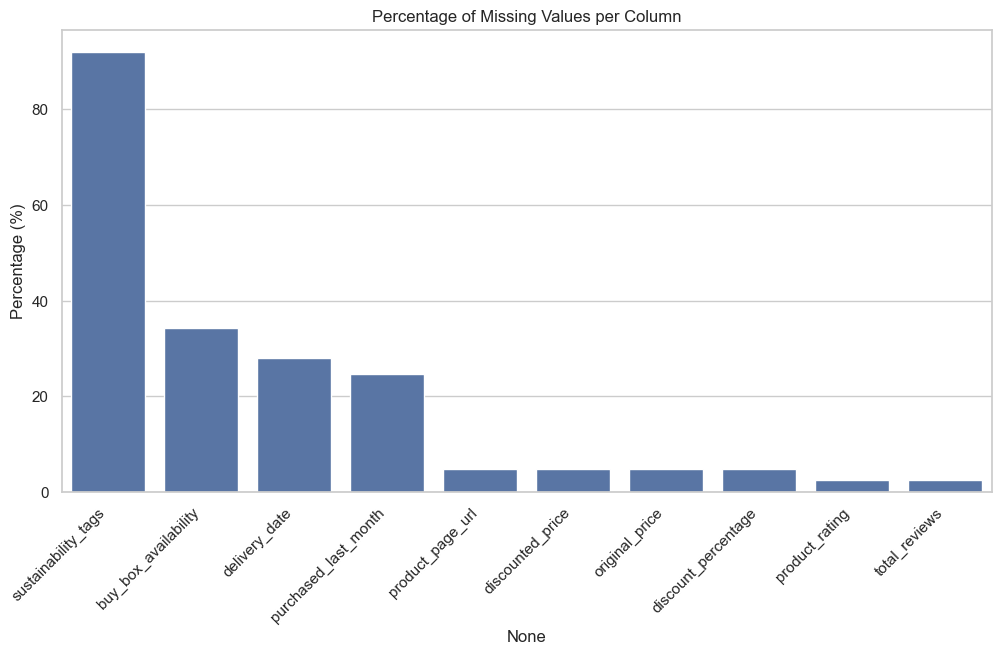

In [6]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

print("Columns with missing values:\n", missing_values)

# Create a dataframe for visualization
missing_df = pd.DataFrame({
    'count': missing_values,
    'percent': missing_percent
})

# Filter and sort columns with missing values
missing_df = missing_df[missing_df['percent'] > 0].sort_values(by='percent', ascending=False)
print("\nColumns with missing data:")
print(missing_df)

# Visualize missing data percentages
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y=missing_df['percent'])
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Cell 7: Exploring Columns

In [7]:
print("Example of 'purchased_last_month':", df['purchased_last_month'].dropna().iloc[0])
print("Example of 'discounted_price':", df['discounted_price'].dropna().iloc[0])
print("Example of 'discount_percentage':", df['discount_percentage'].dropna().iloc[0])
print("Example of 'total_reviews':", df['total_reviews'].dropna().iloc[0])

Example of 'purchased_last_month': 300.0
Example of 'discounted_price': 89.68
Example of 'discount_percentage': 43.6
Example of 'total_reviews': 375.0


1. Sales Target(purchased_last_month):
   * Issue: Contain text and symbols
   * Action Plan: Create a function using Regular Expressions to extract the numbers. Convert final result to an
     int or float.

2. Prices(discounted_price, original_price):
   * Issue: Contains currency symbols and commas
   * Action Plan: Create a function to strip currency symbols and commas, then convert to a float type.

3. Discount(discount_percentage):
   * Issue: Contains the '%' symbol.
   * Action Plan: Create a function to strip symbols, convert to int/float, and divide by 100 to get a float
     representation.

4. Reviews(total_reviews):
   * Issue: May contain commas or shorthand
   * Action Plan: Strip commas. Handle suffixes that are multipliers.  Finally convert to an int.

5. Booleeans(buy_box_availability, has_coupon, is_best_seller):
   * Issue: Missing values.
   * Action Plan: Fill NaN values and standardize the column

# Cell 8: Inspecting Uncleaned String Eamples

In [8]:
print("--- Examples of 'Uncleaned' Data ---")
print(f"purchased_last_month: {df['purchased_last_month'].dropna().iloc[0]}")
print(f"discounted_price: {df['discounted_price'].dropna().iloc[0]}")
print(f"original_price: {df['original_price'].dropna().iloc[0]}")
print(f"dicount_percentage: {df['discount_percentage'].dropna().iloc[0]}")
print(f"total_reviews: {df['total_reviews'].dropna().iloc[0]}")

--- Examples of 'Uncleaned' Data ---
purchased_last_month: 300.0
discounted_price: 89.68
original_price: 159.0
dicount_percentage: 43.6
total_reviews: 375.0


# Cell 9: Temporary Cleaning Function

In [29]:
def clean_sales_volume(volume_str):
    if pd.isna(volume_str):
        return np.nan
    if isinstance(volume_str, (int,float)):
        return volume_str

    volume_str = str(volume_str).lower()

    # Extract Numbers
    numbers = re.findall(r'(\d+\.?\d*)', volume_str)
    if not numbers:
        return np.nan
        
    value = float(numbers[0])
    # Handle 'k' for thousands
    if 'k' in volume_str:
        value *= 1000
    return value

df['sales_volume_numeric'] = df['purchased_last_month'].apply(clean_sales_volume)
print(f"Total rows: {len(df)}")
print(f"Non-null values in cleaned column: {df['sales_volume_numeric'].notnull().sum()}")
print(f"Null values in cleaned column: {df['sales_volume_numeric'].isnull().sum()}")
print("-"*80)
print(df[['purchased_last_month', 'sales_volume_numeric']].head())
print("-"*80)

Total rows: 42675
Non-null values in cleaned column: 32164
Null values in cleaned column: 10511
--------------------------------------------------------------------------------
   purchased_last_month  sales_volume_numeric
0                 300.0                 300.0
1                6000.0                6000.0
2                2000.0                2000.0
3               10000.0               10000.0
4               10000.0               10000.0
--------------------------------------------------------------------------------


# Cell 10: Analyze The Distribution

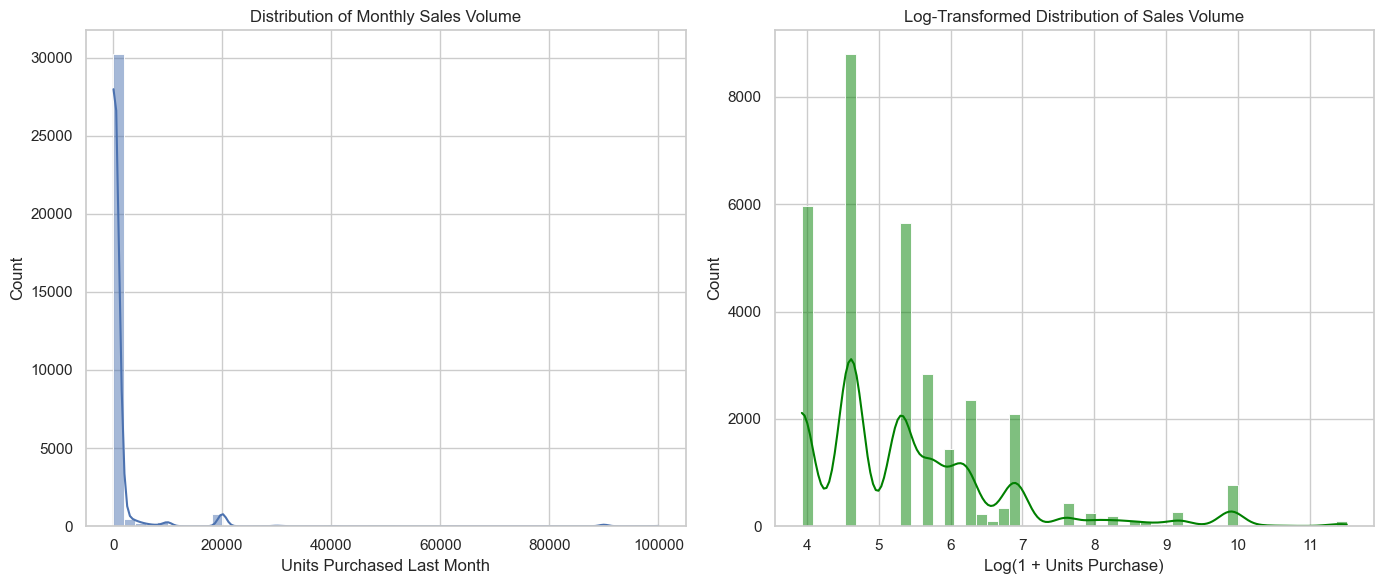

Skewness of original sales data: 10.72363655676025


In [30]:
plt.figure(figsize=(14, 6))

# Histogram of target variable
plt.subplot(1, 2, 1)
sns.histplot(df['sales_volume_numeric'], bins=50, kde=True)
plt.title('Distribution of Monthly Sales Volume')
plt.xlabel('Units Purchased Last Month')

# Histogram of log-transformed target
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['sales_volume_numeric']), bins=50, kde=True, color='green')
plt.title('Log-Transformed Distribution of Sales Volume')
plt.xlabel('Log(1 + Units Purchase)')

plt.tight_layout()
plt.show()

print("Skewness of original sales data:", df['sales_volume_numeric'].skew())

# Cell 11: Clean for correlation analysis

In [33]:
def clean_price(price_str):
    if not isinstance(price_str, str):
        return np.nan

    # Remove non-numeric characters
    match = re.search(r'\d+\.?\d*', price_str.replace(',', ''))
    return float(match.group()) if match else np.nan

def clean_reviews(review_val):
    if pd.isna(review_val):
        return np.nan

    if isinstance(review_val, (int, float)):
        return float(review_val)

    review_str = str(review_val).lower().replace(',', '')

    multiplier = 1
    if 'k' in review_str:
        multiplier = 1000
        review_str = review_str.replace('k','')

    # Extract Number
    numbers = re.findall(r'(\d+\.?\d*)', review_str)
    if not numbers:
        return np.nan

    return float(numbers[0]) * multiplier

# Cell 12: Correlation Analysis

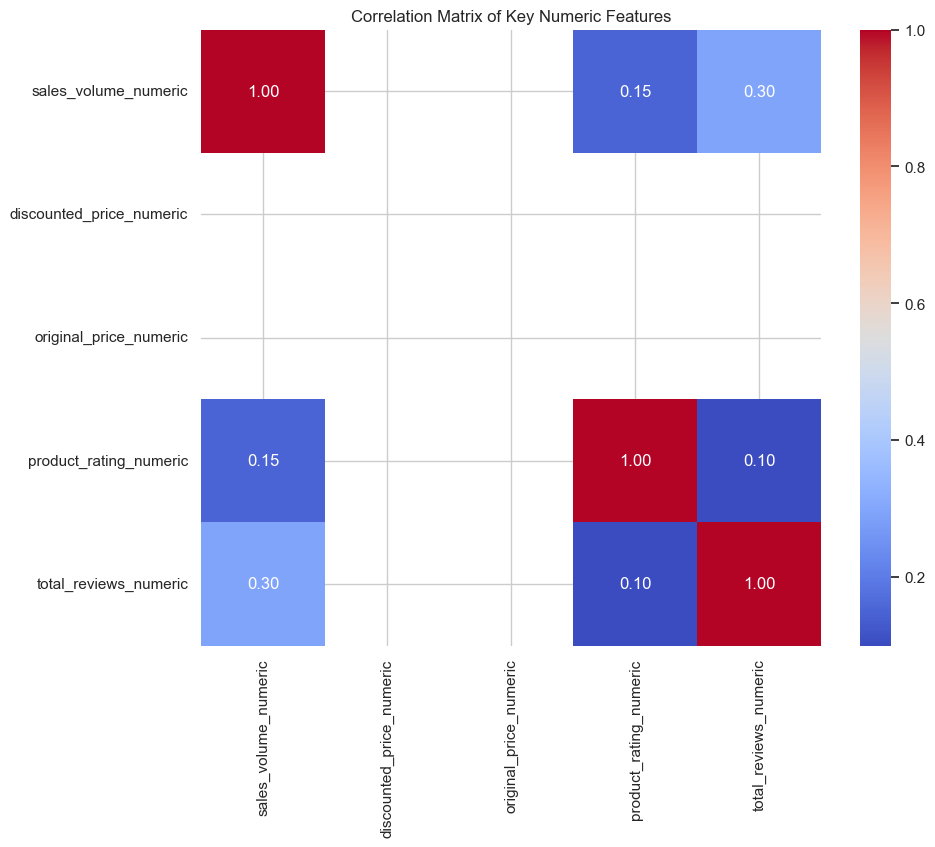

In [34]:
eda_df = df.copy()
eda_df['discounted_price_numeric'] = eda_df['discounted_price'].apply(clean_price)
eda_df['original_price_numeric'] = eda_df['original_price'].apply(clean_price)
eda_df['product_rating_numeric'] = pd.to_numeric(eda_df['product_rating'], errors='coerce')
eda_df['total_reviews_numeric'] = eda_df['total_reviews'].apply(clean_reviews)

# Select cleaned columns for correlation matrix
numeric_cols = ['sales_volume_numeric','discounted_price_numeric', 'original_price_numeric','product_rating_numeric', 'total_reviews_numeric']
corr_matrix = eda_df[numeric_cols].corr()

# Visualize Correlation Matrix with Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Numeric Features')
plt.show()

# Cell 13: Box Plots for Outlier Detection

ValueError: List of boxplot statistics and `positions` values must have same the length

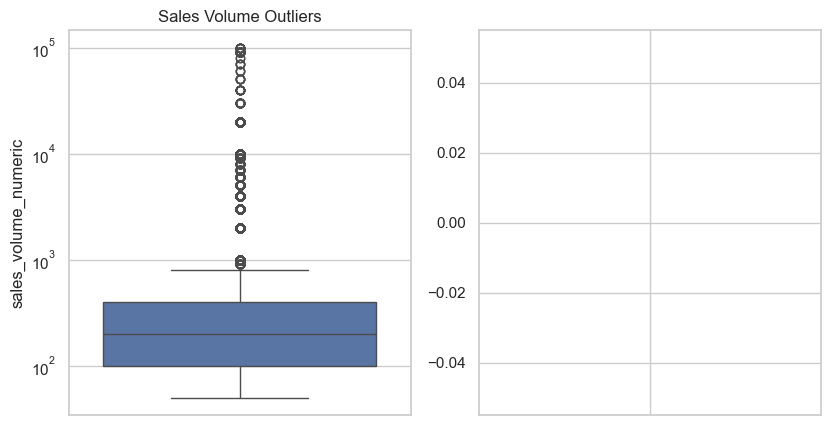

In [35]:
plt.figure(figsize=(15, 5))

# Sales Volume
plt.subplot(1, 3, 1)
sns.boxplot(y=eda_df['sales_volume_numeric'])
plt.title('Sales Volume Outliers')
plt.yscale('log')

# Discounted Price
plt.subplot(1, 3, 2)
sns.boxplot(y=eda_df['discounted_price_numeric'])
plt.title('Discounted Price Outliers')
plt.yscale('log')

# Total Reviews
plt.subplot(1, 3, 3)
sns.boxplot(y=eda_df['total_reviews_numeric'])
plt.title('Total Reviews Outliers')
plt.yscale('log')

plt.tight_layout()
plt.show()